# Load Parsed Table
All three EDA notebooks use the same sections and analysis code; only `DATASET` changes.
They read the complete annotated Parquet, including recovered gene IDs and prepared binary labels.
For data2, `gene_id` identifies a synthetic Curlcake RNA reference, rather than a human gene;
`label = (label_original > 0)`, and the original proportions are retained for inspection.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Search the current working directory and all its parents for the project root.
CWD = Path.cwd().resolve()
ROOT = next(
    (path for path in (CWD, *CWD.parents) if (path / "requirements.txt").is_file()),
    None,
)

if ROOT is None:
    raise RuntimeError(f"Cannot find the project root from working directory: {CWD}")

print(f"Working directory: {CWD}")
print(f"Project root: {ROOT}")

DATASET = "data2"
reads = pd.read_parquet(ROOT / f"data/processed/annotated/{DATASET}_reads.parquet")
reads["label"] = pd.to_numeric(reads["label"], errors="raise")
if not reads["label"].dropna().isin([0, 1]).all():
    raise ValueError("Expected prepared binary labels in the annotated Parquet.")
if reads["gene_id"].isna().any() or reads["gene_id"].str.strip().eq("").any():
    raise ValueError("Missing gene IDs; rerun dataset annotation before EDA.")

SITE_KEYS = ["transcript_id", "transcript_position"]

display(reads.head())
print(f"Read rows: {len(reads):,}")

Working directory: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies
Project root: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies
Read rows: 1,171,940


,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label,gene_id_status,geo_reference_id,geo_reference_center_0based,epinano_reference_id,epinano_reference_center_0based,sequence_only_candidate_count,reference_mapping_status,reference_source,label_original
0,tx_id_0,0,AAAACCT,AAACC,885,0,0.01220,3.99,106.0,0.00337,4.56,102.0,0.00664,4.20,84.2,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,cc6m_2244_t7_ecorv,28,cc6m_2244_T7_ecorv,59,1,unique_7mer_in_curlcake_reference,GEO:GSE124309; EpiNano:Reference_sequences/cc....,1.0
1,tx_id_0,0,AAAACCT,AAACC,885,1,0.03020,2.32,107.0,0.00443,2.36,102.0,0.00332,2.13,79.2,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,cc6m_2244_t7_ecorv,28,cc6m_2244_T7_ecorv,59,1,unique_7mer_in_curlcake_reference,GEO:GSE124309; EpiNano:Reference_sequences/cc....,1.0
2,tx_id_0,0,AAAACCT,AAACC,885,2,0.00232,5.55,110.0,0.00664,7.04,99.3,0.00232,2.21,86.6,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,cc6m_2244_t7_ecorv,28,cc6m_2244_T7_ecorv,59,1,unique_7mer_in_curlcake_reference,GEO:GSE124309; EpiNano:Reference_sequences/cc....,1.0
3,tx_id_0,0,AAAACCT,AAACC,885,3,0.00465,2.10,104.0,0.00996,3.90,108.0,0.00401,2.18,82.2,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,cc6m_2244_t7_ecorv,28,cc6m_2244_T7_ecorv,59,1,unique_7mer_in_curlcake_reference,GEO:GSE124309; EpiNano:Reference_sequences/cc....,1.0
4,tx_id_0,0,AAAACCT,AAACC,885,4,0.02110,3.49,103.0,0.00531,3.80,101.0,0.00997,2.18,81.2,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,cc6m_2244_t7_ecorv,28,cc6m_2244_T7_ecorv,59,1,unique_7mer_in_curlcake_reference,GEO:GSE124309; EpiNano:Reference_sequences/cc....,1.0


# Site Table
For EDA.

In [2]:
# Validate the repeated site metadata before creating site table
site_metadata = [
    "sequence",
    "central_5mer",
    "n_reads",
    "gene_id",
    "label",
]

# Preserve and check annotation provenance when present.
site_metadata += [
    column for column in ["gene_id_status", "label_original", "geo_reference_id"]
    if column in reads.columns
]
assert not reads[SITE_KEYS].isna().any().any(), "Missing site keys."
if "label_original" in reads.columns:
    assert reads["label_original"].between(0, 1).all(), "Invalid original proportions."
    assert reads["label"].eq(reads["label_original"].gt(0).astype(int)).all(), (
        "Binary labels disagree with label_original > 0."
    )

metadata_counts = (
    reads.groupby(SITE_KEYS)[site_metadata]
    .nunique(dropna=False)
)

assert not metadata_counts.gt(1).any().any(), (
    "Some sites have inconsistent metadata."
)

assert not reads.duplicated(
    SITE_KEYS + ["read_idx"]
).any(), "Duplicate read keys found."

assert reads["central_5mer"].eq(
    reads["sequence"].str[1:6]
).all(), "Central 5-mer does not match the sequence."

# Check that the stored count matches the actual number of rows.
coverage_check = (
    reads.groupby(SITE_KEYS)
    .agg(
        observed_reads=("read_idx", "size"),
        stored_n_reads=("n_reads", "first"),
    )
)

assert coverage_check["observed_reads"].eq(
    coverage_check["stored_n_reads"]
).all(), "Stored n_reads does not match the parsed rows."

print("Site metadata and read counts are consistent.")

Site metadata and read counts are consistent.


In [3]:
# One row per site for site-level counts.
sites = (
    reads[SITE_KEYS + site_metadata]
    .drop_duplicates(subset=SITE_KEYS)
    .reset_index(drop=True)
    .copy()
)

# All sites for coverage and data-quality analysis are kept.
# Only labelled records for label comparisons are used.
labelled_sites = sites.dropna(subset=["label"]).copy()
labelled_reads = (
    reads if reads["label"].notna().all()
    else reads.loc[reads["label"].notna()]
)


display(sites.head())

,transcript_id,transcript_position,sequence,central_5mer,n_reads,gene_id,label,gene_id_status,label_original,geo_reference_id
0,tx_id_0,0,AAAACCT,AAACC,885,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,1.0,cc6m_2244_t7_ecorv
1,tx_id_0,10,TGGACCC,GGACC,1069,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,1.0,cc6m_2244_t7_ecorv
2,tx_id_0,20,GGGACTA,GGACT,1933,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,1.0,cc6m_2244_t7_ecorv
3,tx_id_0,30,TGGACCA,GGACC,678,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,1.0,cc6m_2244_t7_ecorv
4,tx_id_0,40,TAGACTA,AGACT,1868,Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,1,not_applicable_synthetic_construct,1.0,cc6m_2244_t7_ecorv


# EDA

## Dataset Summary

In [4]:
summary = pd.Series({
    "site_read_observations": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "gene_id_groups": sites["gene_id"].nunique(),
    "sites_without_gene_ids": int(sites["gene_id"].isna().sum()),
    "sites_without_labels": int(sites["label"].isna().sum()),
    "read_rows_without_labels": int(reads["label"].isna().sum()),
})

display(summary)

# Missing values in each column of the per-read table.
display(
    reads.isna().sum()
    .sort_values(ascending=False)
)

site_read_observations      1171940
sites                          1323
transcripts                       7
gene_id_groups                    4
sites_without_gene_ids            0
sites_without_labels              0
read_rows_without_labels          0
dtype: int64

transcript_id                      0
transcript_position                0
reference_source                   0
reference_mapping_status           0
sequence_only_candidate_count      0
epinano_reference_center_0based    0
epinano_reference_id               0
geo_reference_center_0based        0
geo_reference_id                   0
gene_id_status                     0
label                              0
gene_id                            0
plus1_signal_mean                  0
plus1_signal_sd                    0
plus1_dwell                        0
central_signal_mean                0
central_signal_sd                  0
central_dwell                      0
minus1_signal_mean                 0
minus1_signal_sd                   0
minus1_dwell                       0
read_idx                           0
n_reads                            0
central_5mer                       0
sequence                           0
label_original                     0
dtype: int64

## Label distribution and class balance
All class comparisons use the prepared binary `label` (0 or 1). Counts and percentages
are calculated at site level. For data2, positive original proportions all map to label 1.

,sites,percentage
label,,
0,189,14.285714
1,1134,85.714286


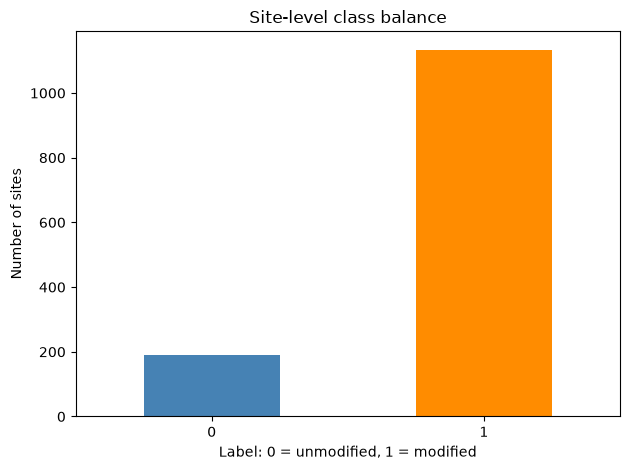

In [5]:
class_counts = (
    labelled_sites["label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .sort_index()
)

class_summary = pd.DataFrame({
    "sites": class_counts,
    "percentage": class_counts / class_counts.sum() * 100,
})

display(class_summary)

class_counts.plot.bar(
    color=["steelblue", "darkorange"],
    rot=0,
)

plt.xlabel("Label: 0 = unmodified, 1 = modified")
plt.ylabel("Number of sites")
plt.title("Site-level class balance")
plt.tight_layout()
plt.show()

## Original labels and transcript consistency
Inspect the preserved source labels (`label_original` when available, otherwise `label`).
These values describe the source annotation; subsequent class comparisons use binary `label`.
A shared value across many sites in one transcript should be considered when interpreting differences.

Source label column: label_original
Among complete multi-site transcripts, percentage with one shared source annotation value: 100.0%


count    1323.000000
mean        0.592857
std         0.339696
min         0.000000
25%         0.250000
50%         0.700000
75%         0.950000
max         1.000000
Name: label_original, dtype: float64

,sites,percentage_of_nonmissing_sites
label_original,,
0.00,189,14.285714
0.25,189,14.285714
0.50,189,14.285714
0.70,189,14.285714
0.75,189,14.285714
0.95,189,14.285714
1.00,189,14.285714


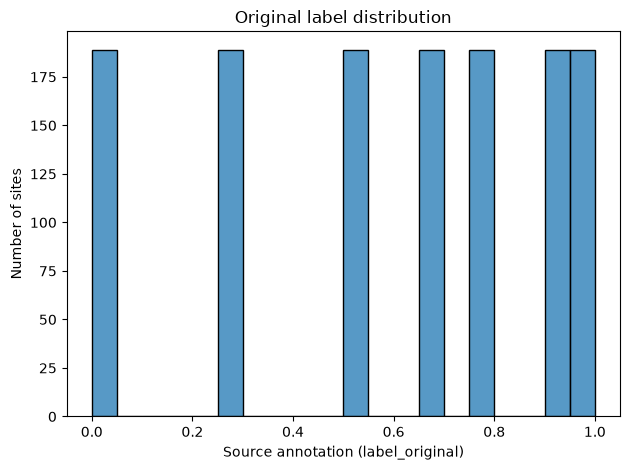

,n_sites,n_distinct_values,n_missing_values
transcript_id,,,
tx_id_0,189,1,0
tx_id_1,189,1,0
tx_id_2,189,1,0
tx_id_3,189,1,0
tx_id_4,189,1,0
tx_id_5,189,1,0
tx_id_6,189,1,0


In [6]:
source_label_column = "label_original" if "label_original" in sites.columns else "label"
values = sites[source_label_column].dropna()
print(f"Source label column: {source_label_column}")
display(values.describe())
value_counts = values.value_counts().sort_index()
display(pd.DataFrame({
    "sites": value_counts,
    "percentage_of_nonmissing_sites": 100 * value_counts / value_counts.sum(),
}))
sns.histplot(values, bins=20, binrange=(0, 1))
plt.xlabel(f"Source annotation ({source_label_column})")
plt.ylabel("Number of sites")
plt.title("Original label distribution")
plt.tight_layout()
plt.show()

per_transcript = sites.groupby("transcript_id").agg(
    n_sites=("transcript_position", "size"),
    n_distinct_values=(source_label_column, "nunique"),
    n_missing_values=(source_label_column, lambda x: x.isna().sum()),
)
display(per_transcript.head(10))
eligible = per_transcript.loc[
    (per_transcript["n_sites"] > 1) & (per_transcript["n_missing_values"] == 0)
]
if not eligible.empty:
    constant_fraction = eligible["n_distinct_values"].eq(1).mean()
    print("Among complete multi-site transcripts, percentage with one shared "
          f"source annotation value: {100 * constant_fraction:.1f}%")

## Read coverage
Sites with few reads may have less stable summary statistics.

count    1323.000000
mean      885.820106
std       564.544252
min        26.000000
1%         50.000000
5%        112.000000
25%       440.000000
50%       814.000000
75%      1269.500000
95%      1868.000000
99%      2395.120000
max      3438.000000
Name: n_reads, dtype: float64

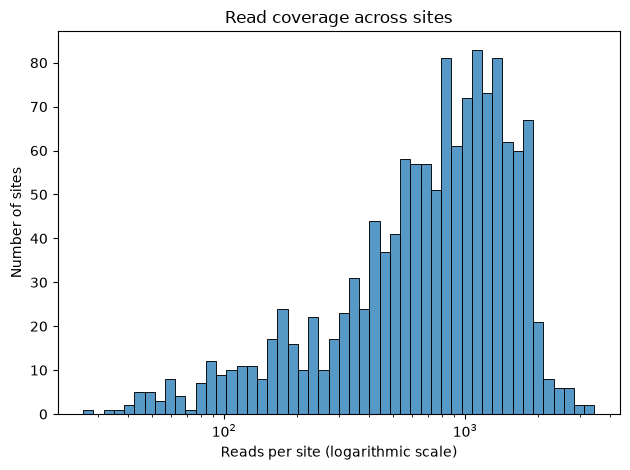

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,189.0,1233.507937,384.539689,329.0,956.00,1205.0,1505.00,1958.0
1,1134.0,827.872134,569.045321,26.0,391.25,724.0,1169.75,3438.0


In [7]:
display(
    sites["n_reads"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

sns.histplot(
    data=sites,
    x="n_reads",
    bins=50,
    log_scale=True,
)

plt.xlabel("Reads per site (logarithmic scale)")
plt.ylabel("Number of sites")
plt.title("Read coverage across sites")
plt.tight_layout()
plt.show()

display(
    labelled_sites.groupby("label")["n_reads"].describe()
)

In [8]:
# Descriptive cutoffs for EDA, not filtering rules.
coverage_summary = pd.DataFrame([
    {
        "condition": f"n_reads < {cutoff}",
        "sites": int((sites["n_reads"] < cutoff).sum()),
        "percentage": 100 * (sites["n_reads"] < cutoff).mean(),
    }
    for cutoff in [5, 10, 20]
])

display(coverage_summary)

,condition,sites,percentage
0,n_reads < 5,0,0.0
1,n_reads < 10,0,0.0
2,n_reads < 20,0,0.0


## Sites per gene ID
These are transcript-position sites, not unique genomic loci. Human datasets group by recovered
gene ID; data2 groups by synthetic RNA reference ID stored in `gene_id`.

count      4.00000
mean     330.75000
std       60.58809
min      252.00000
25%      309.75000
50%      336.00000
75%      357.00000
max      399.00000
Name: n_sites, dtype: float64

,n_sites
gene_id,
Synthetic Curlcake RNA: cc6m_2709_t7_ecorv,399
Synthetic Curlcake RNA: cc6m_2595_t7_ecorv,343
Synthetic Curlcake RNA: cc6m_2459_t7_ecorv,329
Synthetic Curlcake RNA: cc6m_2244_t7_ecorv,252


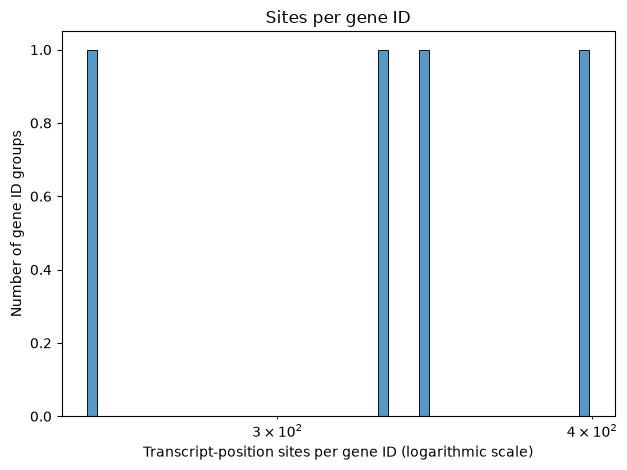

In [9]:
sites_per_gene = (
    sites.dropna(subset=["gene_id"])
    .groupby("gene_id")
    .size()
    .rename("n_sites")
    .sort_values(ascending=False)
)

display(sites_per_gene.describe())
display(sites_per_gene.head(5).to_frame())

sns.histplot(
    x=sites_per_gene,
    bins=50,
    log_scale=True,
)

plt.xlabel("Transcript-position sites per gene ID (logarithmic scale)")
plt.ylabel("Number of gene ID groups")
plt.title("Sites per gene ID")
plt.tight_layout()
plt.show()

## Sites per transcript

count      7.0
mean     189.0
std        0.0
min      189.0
25%      189.0
50%      189.0
75%      189.0
max      189.0
Name: n_sites, dtype: float64

,n_sites
transcript_id,
tx_id_0,189
tx_id_1,189
tx_id_2,189
tx_id_3,189
tx_id_4,189
tx_id_5,189
tx_id_6,189


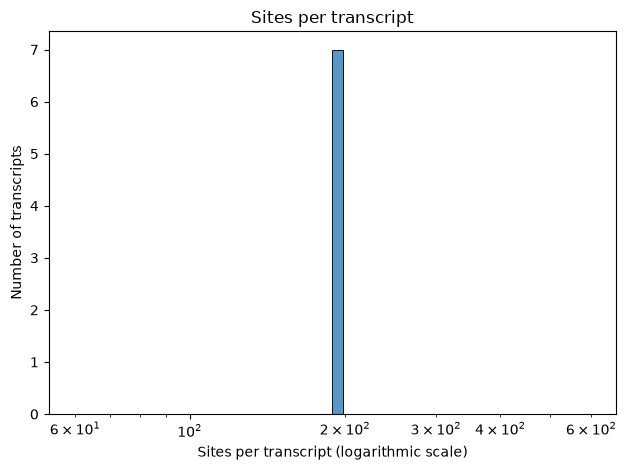

In [10]:
sites_per_transcript = (
    sites.groupby("transcript_id").size().rename("n_sites").sort_values(ascending=False)
)
display(sites_per_transcript.describe())
display(sites_per_transcript.head(10).to_frame())
sns.histplot(x=sites_per_transcript, bins=50, log_scale=True)
plt.xlabel("Sites per transcript (logarithmic scale)")
plt.ylabel("Number of transcripts")
plt.title("Sites per transcript")
plt.tight_layout()
plt.show()

## Overall 7-mer and central 5-mer frequencies

,sites
sequence,
GTAACAT,28
TGGACCC,21
TAGACTA,21
CAAACCC,21
GAGACAG,21
TTAACCA,21
AAGACAG,21
TAAACTG,21
CGAACCT,21


,sites
central_5mer,
AGACA,105
GGACT,98
TAACA,98
GGACC,91
AGACT,84
TAACT,84
GAACA,84
AAACA,77
GAACC,77


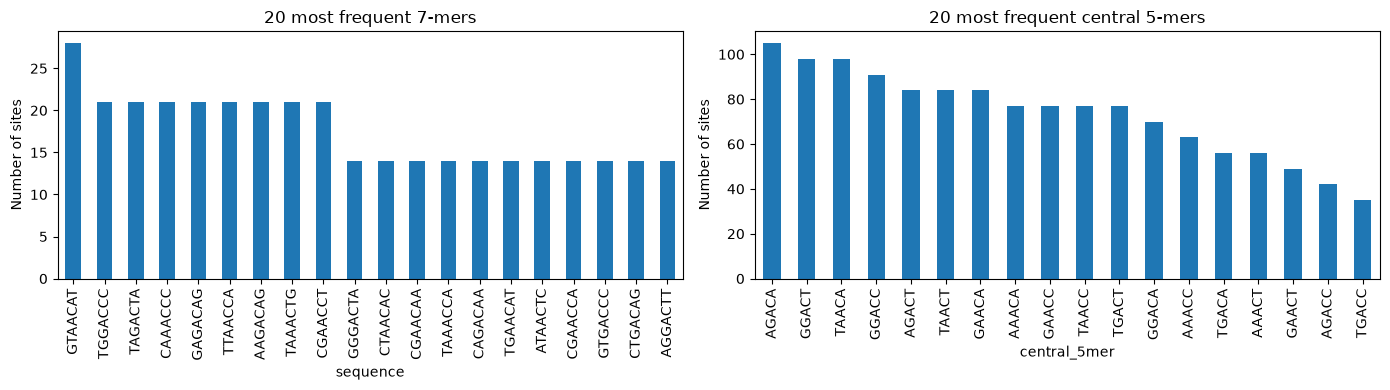

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, column, title in zip(axes, ["sequence", "central_5mer"], ["7-mers", "central 5-mers"]):
    counts = sites[column].value_counts().head(20)
    display(counts.rename("sites").to_frame())
    counts.plot.bar(ax=ax)
    ax.set_title(f"20 most frequent {title}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of sites")
plt.tight_layout()
plt.show()

## Full 7-mer freq by label
The plotted percentages use all sites in each class as the denominator, not just the top 20 sequences.

label,0,1
sequence,,
GTAACAT,4,24
AAGACAG,3,18
CAAACCC,3,18
CGAACCT,3,18
GAGACAG,3,18
TAAACTG,3,18
TAGACTA,3,18
TGGACCC,3,18
TTAACCA,3,18


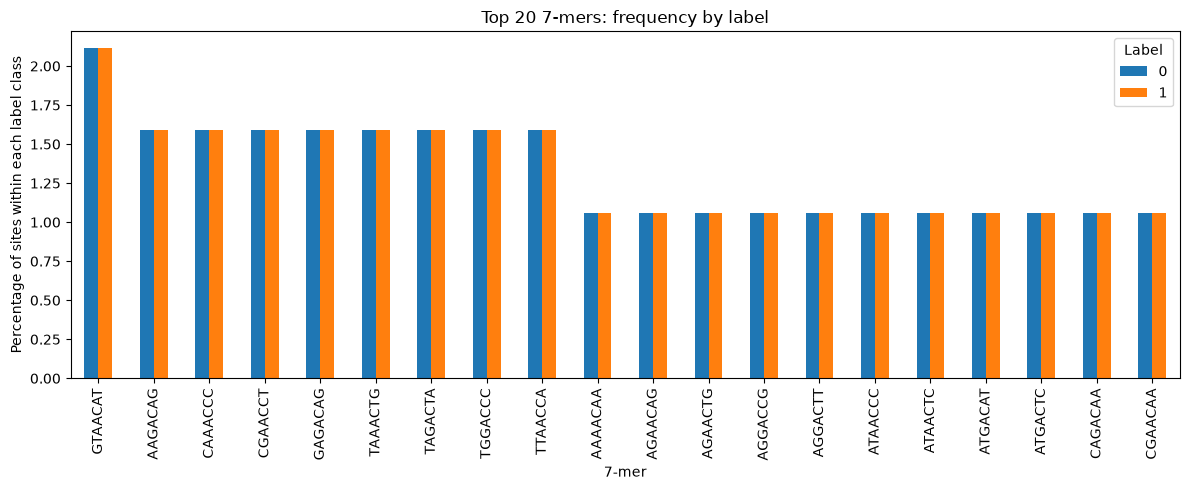

In [12]:
sequence_counts = pd.crosstab(
    labelled_sites["sequence"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("7-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 7-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## 5-mer freq by label

label,0,1
central_5mer,,
AGACA,15,90
GGACT,14,84
TAACA,14,84
GGACC,13,78
AGACT,12,72
GAACA,12,72
TAACT,12,72
AAACA,11,66
GAACC,11,66


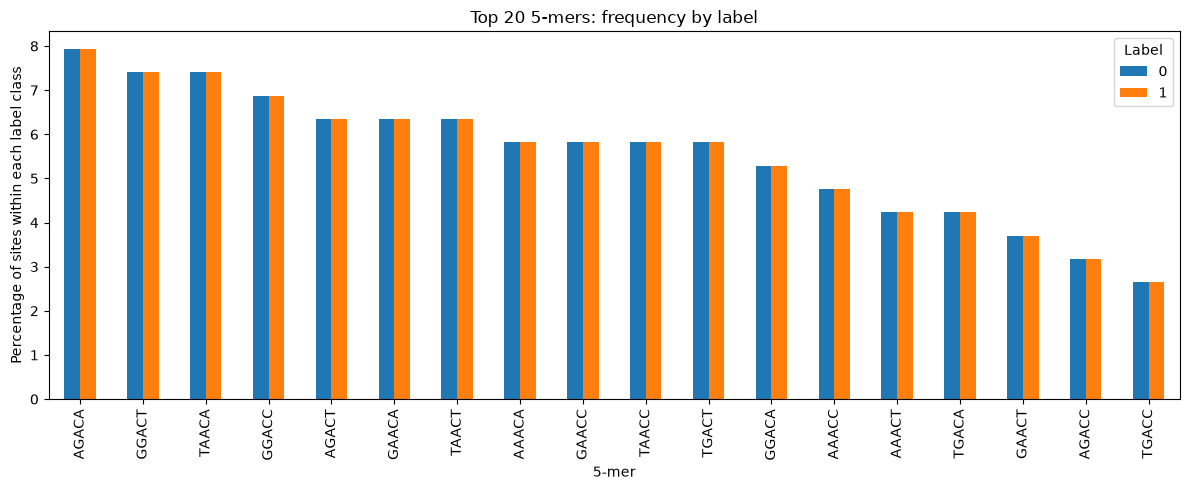

In [13]:
sequence_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("5-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 5-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## Sequence motifs
Interpret positive fractions alongside site counts: a motif represented by very few sites has a less reliable estimate.

label,unmodified_sites,modified_sites,total_sites,positive_fraction
central_5mer,,,,
AGACA,15,90,105,0.857143
TAACA,14,84,98,0.857143
GGACT,14,84,98,0.857143
GGACC,13,78,91,0.857143
TAACT,12,72,84,0.857143
AGACT,12,72,84,0.857143
GAACA,12,72,84,0.857143
AAACA,11,66,77,0.857143
TAACC,11,66,77,0.857143


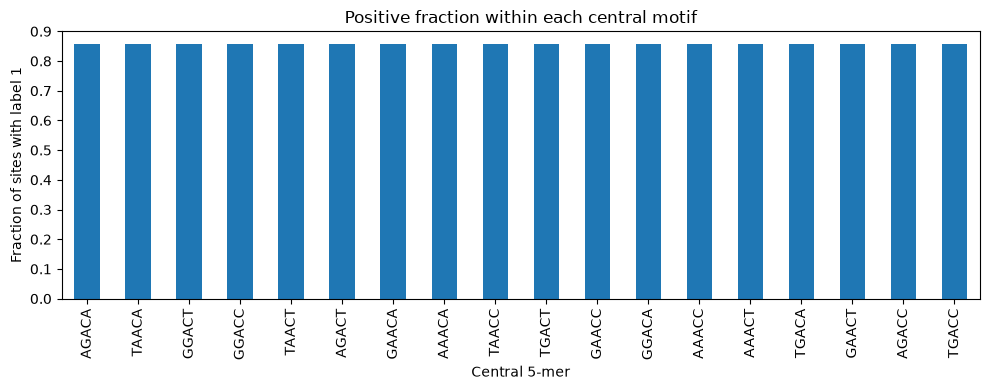

In [14]:
motif_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

motif_summary = motif_counts.rename(
    columns={0: "unmodified_sites", 1: "modified_sites"}
)

motif_summary["total_sites"] = motif_summary.sum(axis=1)

motif_summary["positive_fraction"] = (
    motif_summary["modified_sites"]
    / motif_summary["total_sites"]
)

motif_summary = motif_summary.sort_values(
    "total_sites", ascending=False
)

display(motif_summary)

motif_summary["positive_fraction"].plot.bar(
    figsize=(10, 4)
)

plt.xlabel("Central 5-mer")
plt.ylabel("Fraction of sites with label 1")
plt.title("Positive fraction within each central motif")
plt.tight_layout()
plt.show()

In [15]:
# Data-quality check to investigate unexpected motifs before deciding whether to exclude anything  
valid_motif = sites["central_5mer"].str.fullmatch(
    r"[AGT][AG]AC[ACT]",
    na=False,
)

print("Sites outside the expected DRACH motif:", (~valid_motif).sum())

display(
    sites.loc[
        ~valid_motif,
        SITE_KEYS + ["sequence", "central_5mer"]
    ].head()
)

Sites outside the expected DRACH motif: 0


,transcript_id,transcript_position,sequence,central_5mer


## Central signal features
Compare all labelled read observations by binary label. High-coverage sites contribute more
observations. Boxplots hide outliers visually; no finite observations are discarded as outliers.

central_dwell, label 0: 0 non-finite observations excluded.
central_dwell, label 1: 0 non-finite observations excluded.
central_signal_sd, label 0: 0 non-finite observations excluded.
central_signal_sd, label 1: 0 non-finite observations excluded.
central_signal_mean, label 0: 0 non-finite observations excluded.
central_signal_mean, label 1: 0 non-finite observations excluded.


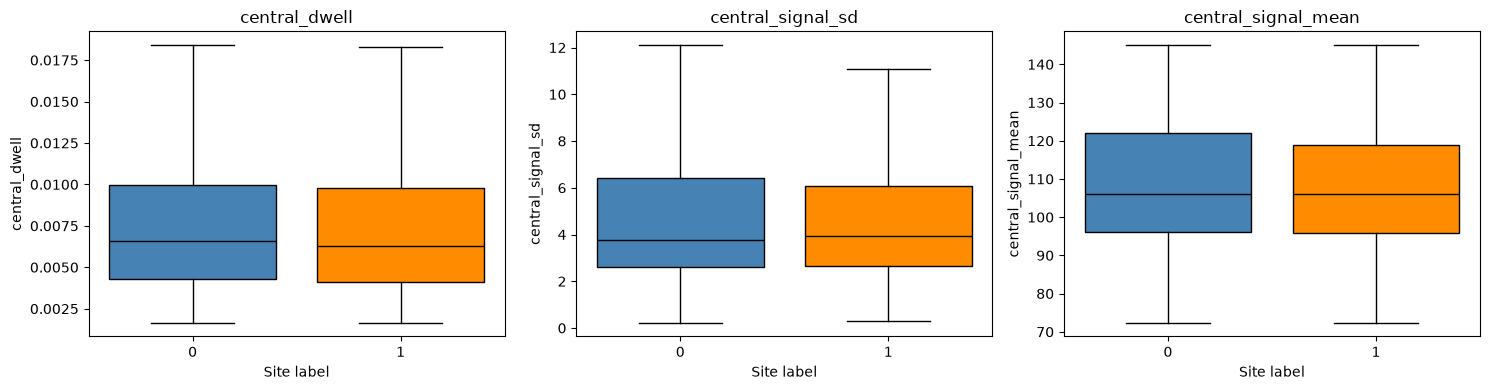

In [16]:
central_features = ["central_dwell", "central_signal_sd", "central_signal_mean"]


def plot_signal_by_label(frame, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, feature in zip(axes, central_features):
        groups, group_names = [], []
        for label in [0, 1]:
            values = pd.to_numeric(
                frame.loc[frame["label"].eq(label), feature], errors="raise",
            ).to_numpy(dtype=float, na_value=np.nan)
            finite = np.isfinite(values)
            print(f"{title_prefix}{feature}, label {label}: "
                  f"{(~finite).sum():,} non-finite observations excluded.")
            if finite.any():
                groups.append(values[finite])
                group_names.append(str(label))
        if not groups:
            ax.set_title(f"{title_prefix}{feature}: no valid observations")
            ax.axis("off")
            continue
        positions = np.arange(1, len(groups) + 1)
        box = ax.boxplot(groups, positions=positions, widths=0.8,
                         showfliers=False, patch_artist=True,
                         medianprops={"color": "black"})
        for patch, label in zip(box["boxes"], group_names):
            patch.set_facecolor({"0": "steelblue", "1": "darkorange"}[label])
        ax.set_xticks(positions)
        ax.set_xticklabels(group_names)
        ax.set_xlabel("Site label")
        ax.set_ylabel(feature)
        ax.set_title(f"{title_prefix}{feature}")
    plt.tight_layout()
    plt.show()


plot_signal_by_label(labelled_reads)

## Compare site averages
Average the read signals within each site, then attach its binary label. Each site receives
equal weight; sites from the same gene or synthetic RNA reference may still be related.

Site average: central_dwell, label 0: 0 non-finite observations excluded.
Site average: central_dwell, label 1: 0 non-finite observations excluded.
Site average: central_signal_sd, label 0: 0 non-finite observations excluded.
Site average: central_signal_sd, label 1: 0 non-finite observations excluded.
Site average: central_signal_mean, label 0: 0 non-finite observations excluded.
Site average: central_signal_mean, label 1: 0 non-finite observations excluded.


label
0     189
1    1134
Name: sites, dtype: int64

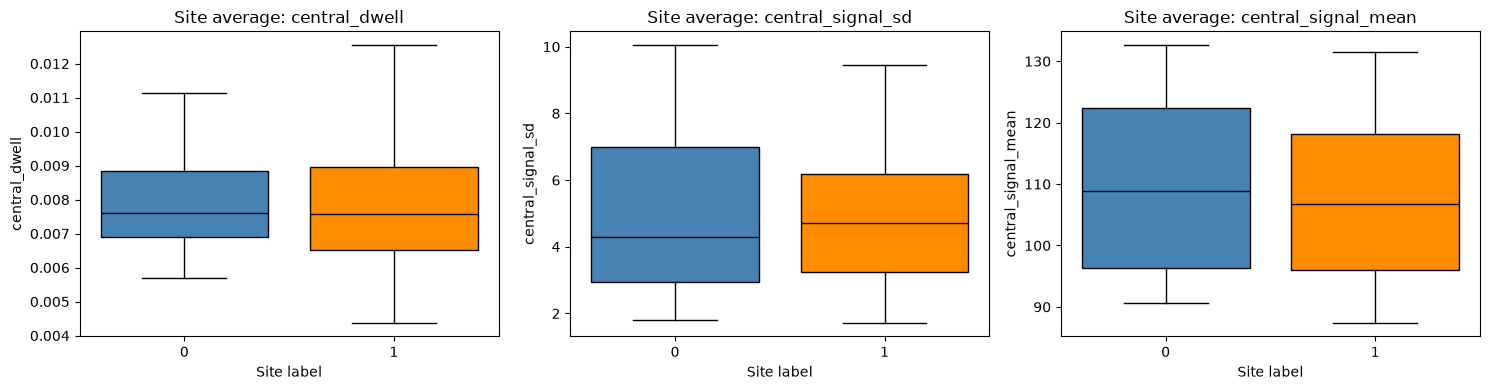

In [17]:
central_site_means = (
    labelled_reads.groupby(SITE_KEYS, as_index=False)[central_features].mean()
    .merge(labelled_sites[SITE_KEYS + ["label"]], on=SITE_KEYS, validate="one_to_one")
)
display(central_site_means.groupby("label").size().rename("sites"))
plot_signal_by_label(central_site_means, title_prefix="Site average: ")